In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [24]:
from src.vessel_data import VesselDataProcessor
# Path to your raw telemetry
raw_data_file = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"

# Instantiate
processor = VesselDataProcessor(raw_data_file)

# The new load_data now stops before the definitions footer
processor.load_data(time_col="Sample time", date_format="%d/%m/%y %H:%M")

# Check if the last rows are actual data and not 'Tag Name' strings
print(processor.df.tail()) 

# Extract metadata separately to verify definitions (WP9 context)
metadata_df = processor.extract_metadata()
print(metadata_df)

# Run sanity checks on the cleaned data
processor.sanity_check()

Successfully loaded 2880 telemetry rows.
             Sample time  AE_POWER(kW)  DG_1_POWER(GByte)  DG_2_POWER(GByte)  \
2875 2025-12-31 23:40:00     377.93892             1584.0              784.0   
2876 2025-12-31 23:45:00     380.87293             1584.0              784.0   
2877 2025-12-31 23:50:00     386.18563             1584.0              784.0   
2878 2025-12-31 23:55:00     385.93173             1584.0              784.0   
2879 2026-01-01 00:00:00     389.06704             1584.0              784.0   

      DG_3_POWER(GByte)  GE162(kW)  GE163(A)  GE164  GE262(kW)   GE263(A)  \
2875             1494.0        0.0       0.0    0.0  378.47263  575.62134   
2876             1494.0        0.0       0.0    0.0  382.22141  581.09136   
2877             1494.0        0.0       0.0    0.0  385.98485  589.18860   
2878             1494.0        0.0       0.0    0.0  386.04467  585.44749   
2879             1494.0        0.0       0.0    0.0  389.93814  590.59071   

      ...  GE36

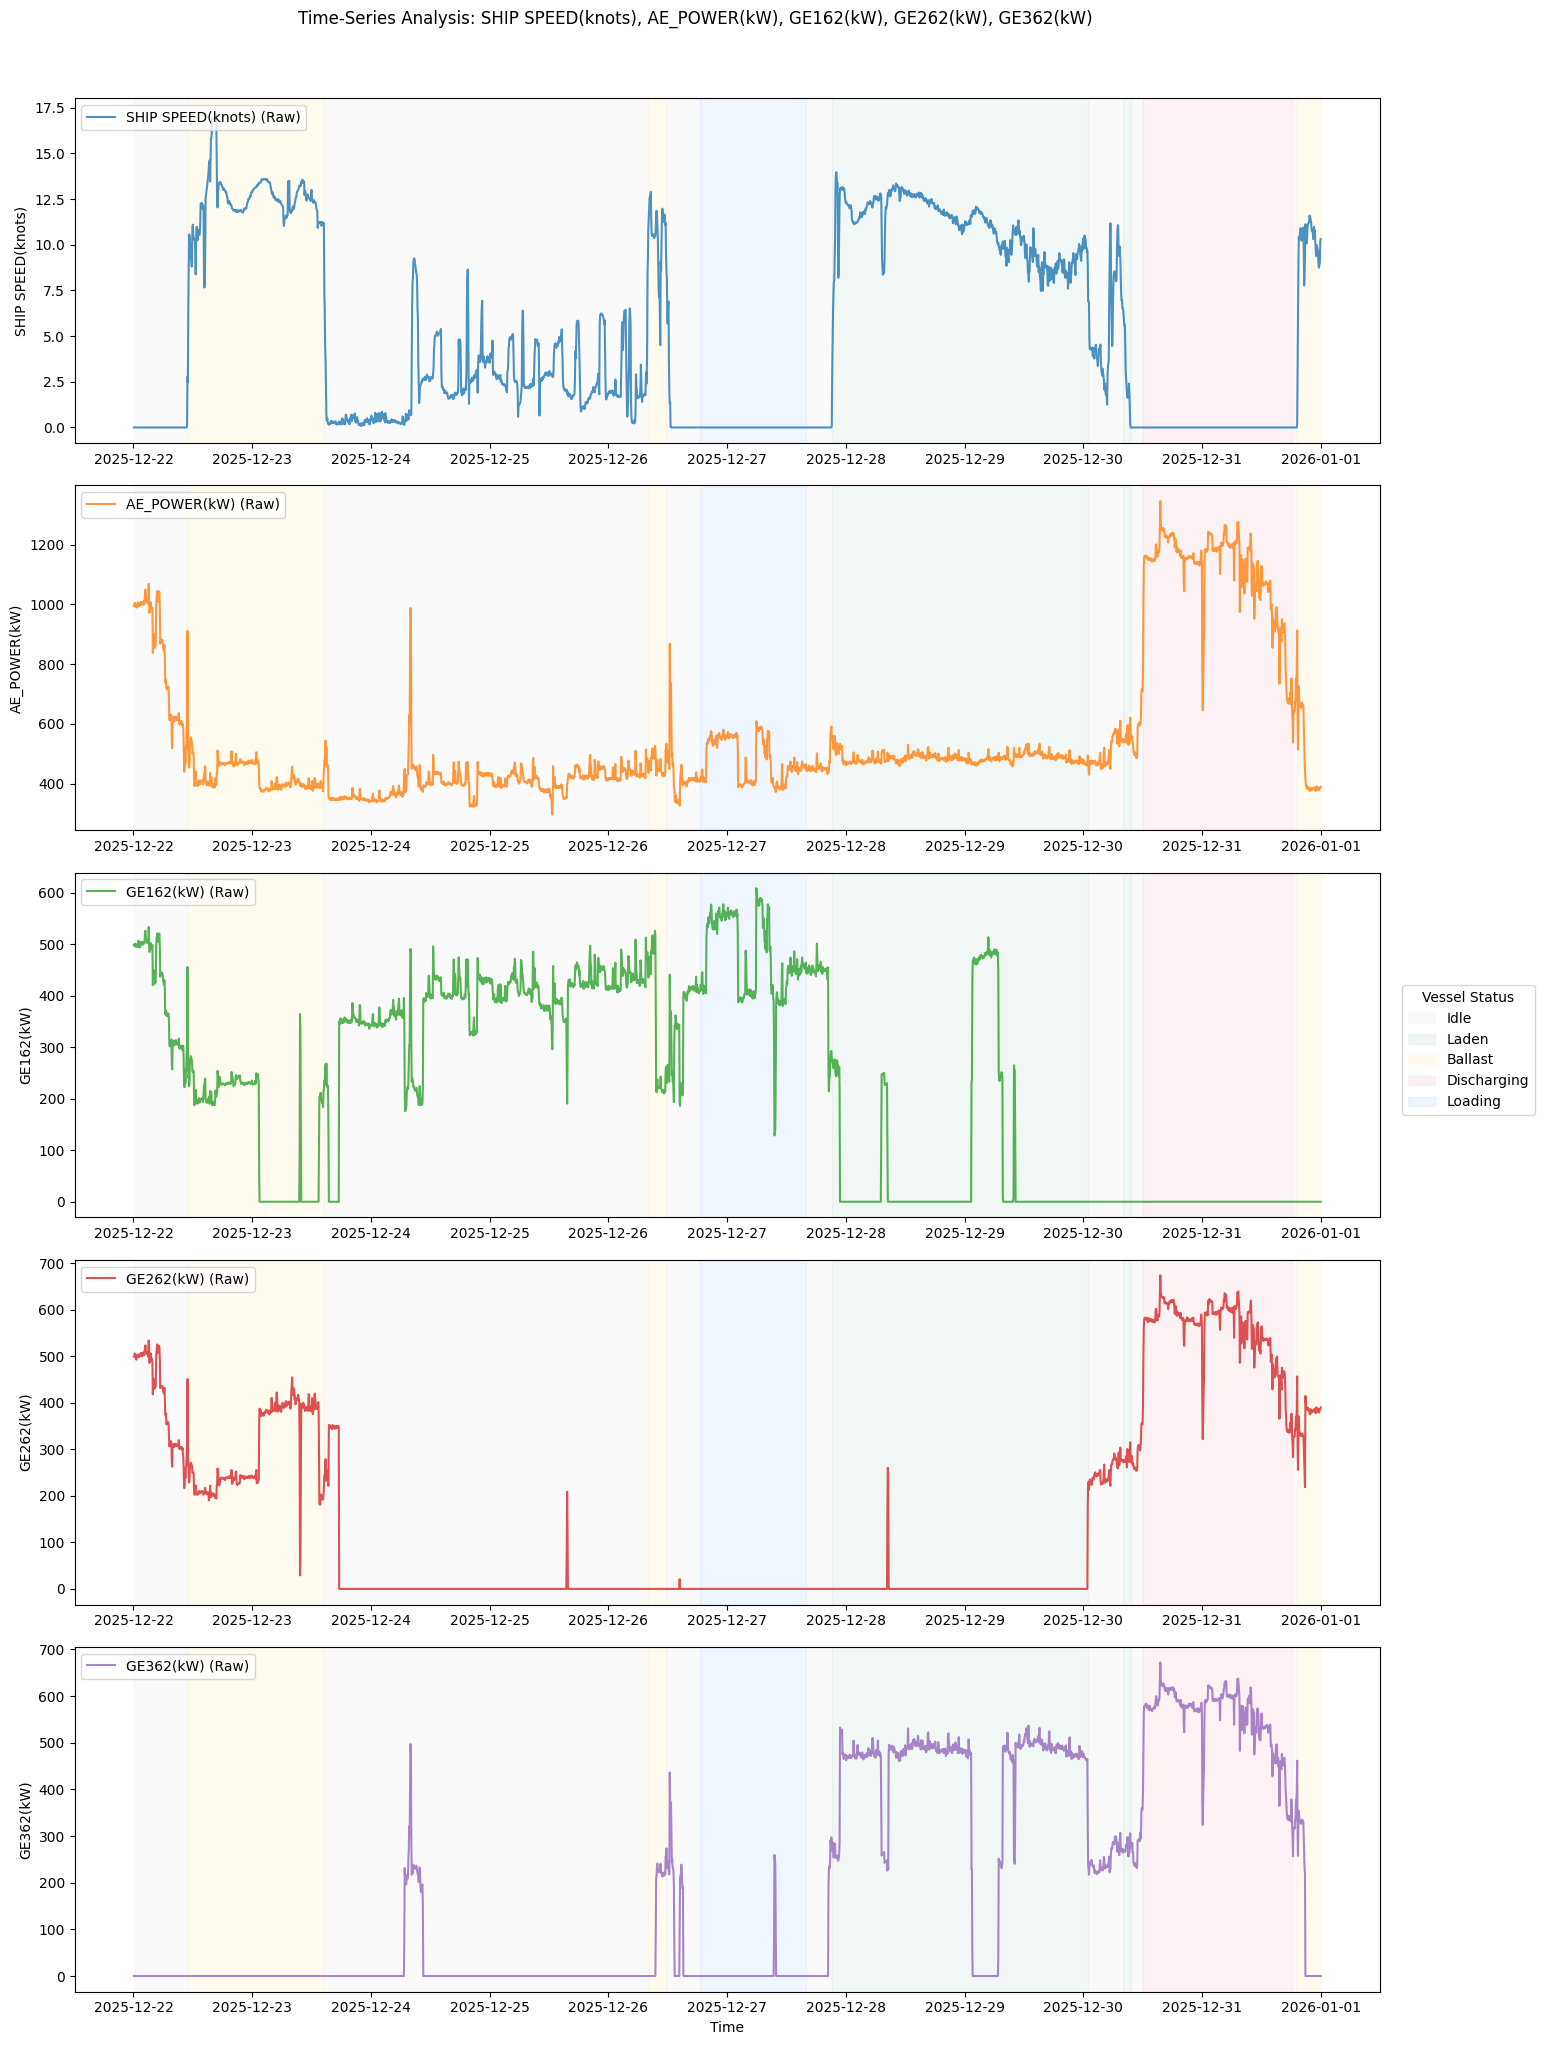

In [25]:
# Let's plot Total Power vs Ship Speed
cols_to_plot = ['SHIP SPEED(knots)', 'AE_POWER(kW)', 'GE162(kW)', 'GE262(kW)', 'GE362(kW)']

# We capture fig, axes so we can modify them!
fig, axes = processor.plot_series(
    columns=cols_to_plot, 
    subplots=True,
    show_status=True,
)
